# SAT formula generator

In [1]:
import random
import math
import numpy as np

class kSATGenerator:
    def __init__(self, num_clauses, num_vars, k, seed=None):
        self.num_clauses = num_clauses
        self.num_vars = num_vars
        self.k = k
        self.random = random.Random(seed)

    def generate(self):
        max_num_clauses = 2**self.k * math.comb(self.num_vars, self.k)
        if self.num_clauses > max_num_clauses:
            raise ValueError("Too many clauses")
        
        vars_list = list(range(1, self.num_vars + 1))
        clauses = set()

        while len(clauses) < self.num_clauses:
            variables = sorted(self.random.sample(vars_list, self.k))
            literals = [var * self.random.choice([1, -1]) for var in variables]
            clause = tuple(literals)
            clauses.add(clause)

        return list(clauses)
    
class Pos1in2SATGenerator:
    def __init__(self, num_clauses, num_vars, k, seed=None):
        self.num_clauses = num_clauses
        self.num_vars = num_vars
        self.k = k
        self.random = random.Random(seed)

    def generate(self):
        max_num_clauses = math.comb(self.num_vars, self.k)
        if self.num_clauses > max_num_clauses:
            raise ValueError("Too many clauses")
        
        vars_list = list(range(1, self.num_vars + 1))
        clauses = set()

        while len(clauses) < self.num_clauses:
            variables = sorted(self.random.sample(vars_list, self.k))
            literals = variables
            clause = tuple(literals)
            clauses.add(clause)

        return list(clauses)


threesat_generator = kSATGenerator(5, 4, 3, seed=42)
formula = threesat_generator.generate()
print(formula)

pos1in2sat_generator = Pos1in2SATGenerator(5, 4, 2, seed=42)
formula = pos1in2sat_generator.generate()
print(formula)

[(2, 3, -4), (-1, 3, 4), (1, -2, 3), (1, 3, -4), (1, 2, 4)]
[(1, 2), (3, 4), (1, 4), (2, 3), (1, 3)]


# Utilities functions on formulas

In [2]:
def get_num_clauses(formula):
    return len(formula)

def get_num_variables(formula):
    return int(np.max(np.abs(np.array(formula).flatten()))) # cast to int to avoid fixed size np.int64

def get_k(formula):
    return len(formula[0])

## Brute force solver

In [3]:
def brute_force_solve(formula, one_in_k=False):
    num_variables = get_num_variables(formula)
    for n in range(2**num_variables):
        #bitstring = [(n >> i) & 1 for i in reversed(range(num_variables))]
        violated_count = 0
        for clause in formula:
            true_count = 0
            for literal in clause:
                var_index = abs(literal) - 1
                value = (n >> var_index) & 1
                if literal < 0:
                    value = 1 - value
                    
                true_count += value
            if one_in_k:
                if true_count != 1:
                    violated_count += 1
            else:
                if true_count == 0:
                    violated_count += 1
        if violated_count == 0:
            bitstring = format(n, f"0{num_variables}b")
            return bitstring
    return None

# Formula evaluator

In [4]:
def count_violated_clauses(formula, bitstring, one_in_k=False):
    violated_count = 0
    for clause in formula:
        true_literals_count = 0
        for literal in clause:
            var_index = abs(literal) - 1
            bit_value = int(bitstring[-(var_index + 1)])
            var_value = bit_value if literal > 0 else (1 - bit_value)
            true_literals_count += var_value

        if one_in_k:
            if true_literals_count != 1: # exactly one True needed
                violated_count += 1
        else:
            if true_literals_count == 0: # at least one True needed
                violated_count += 1
    return violated_count

bitstring = "1001"
print(count_violated_clauses(formula, bitstring, one_in_k=False))
print(count_violated_clauses(formula, bitstring, one_in_k=True))

1
2


# Test cases

In [5]:
test_cases = [
    ([(1, 2), (-1, 3)], "101", False, 0),
    ([(1, 2), (-1, 3)], "100", False, 1),
    ([(1, 2), (-1, 3)], "000", False, 1),
    ([(-1, -2)], "10", False, 0),
    ([(-1, -2)], "11", False, 1),
    ([(1, 2, 3)], "001", True, 0),
    ([(1, 2, 3)], "000", True, 1),
    ([(1, 2, 3)], "011", True, 1),
    ([(1, -2), (2, 3, -1)], "001", True, 2),
    ([(-1, 2, -3)], "001", True, 0),
    ([(-1, 2, -3)], "011", True, 1),
]

for i, (formula, bitstring, one_in_k, expected) in enumerate(test_cases, 1):
    result = count_violated_clauses(formula, bitstring, one_in_k)
    assert result == expected, f"Test case {i} failed: got {result}, expected {expected}"


def test_random_bruteforce(num_tests=5, num_clauses=3, num_vars=4, k=3, one_in_k=False, seed=None):
    sat_generator = kSATGenerator(num_clauses, num_vars, k, seed)
    
    for i in range(num_tests):
        formula = sat_generator.generate()
        solution = brute_force_solve(formula, one_in_k=one_in_k)
        
        
        if solution is not None:
            violated_count = count_violated_clauses(formula, solution, one_in_k)
            assert violated_count == 0, f"Test {i+1} failed: solution violates {violated_count} clauses"
    
    print("All tests passed")


test_random_bruteforce(num_tests=20, k=3, one_in_k=False)
test_random_bruteforce(num_tests=20, k=3, one_in_k=True)
    

All tests passed
All tests passed


# Hamiltonian calculator

In [6]:
from scipy.sparse import diags

def ksat_hamiltonian(formula):
    n_vars = get_num_variables(formula)

    dim = 2 ** n_vars
    H_diag = np.zeros(dim, dtype=int)

    for clause in formula:
        ith_term = np.ones(2 ** n_vars, dtype=int)
        for literal in clause:
            variable_idx = np.abs(literal) - 1
            
            states = np.arange(dim)
            bits = (states >> variable_idx) & 1
            if literal > 0:
                proj = 1 - bits
            else:
                proj = bits
            ith_term *= proj
        H_diag += ith_term
    H = diags(H_diag, 0, format='csr')
    return H

    

## Test Hamiltonian calculator

In [7]:
test_sat_generator = kSATGenerator(20, 20, 3, seed=42)
formula = test_sat_generator.generate()
print("formula: ", formula)
n_vars = get_num_variables(formula)
print("n_vars: ", n_vars)
dim = 2 ** n_vars
print("dim: ", dim)

H = ksat_hamiltonian(formula)
H_diag = H.diagonal()
assert len(H_diag) == dim
print("Hamiltonian: ", H_diag)

for state in range(dim):
    bitstring = format(state, f"0{n_vars}b")
    assert H_diag[state] == count_violated_clauses(formula, bitstring)
    #print(f"{bitstring} | {H_diag[state]} | {violated}")

formula:  [(-3, -4, -13), (3, 7, 9), (9, -12, -15), (7, -11, -19), (5, 9, -15), (-3, 4, 18), (3, 16, 17), (-3, -6, -14), (10, 12, 18), (2, -15, 18), (8, 9, -15), (3, 7, -8), (9, -13, 15), (-13, 14, 19), (-4, 10, -11), (1, 4, 9), (5, -9, 11), (3, 8, -10), (-2, -8, 11), (9, 17, -18)]
n_vars:  19
dim:  524288


/tmp/ipykernel_3456/3242546201.py:22: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  H = diags(H_diag, 0, format='csr')


Hamiltonian:  [4. 3. 4. ... 2. 2. 2.]


# List generator for SparsePauliOp

$H_{C, k} = \frac{1}{2^k} \sum_{a=1}^m \prod_{l=1}^k (1+A_{a_l, a} Z_{a_l})$

$H_{C, 2^+} = \frac{1}{4} \sum_{a=1}^m (Z_{a_1} + Z_{a_2})^2 = \frac{1}{2} \sum_{a=1}^m (1 + Z_{a_1} Z_{a_2})$

$H_{C, 3^+} = \frac{1}{4} \sum_{a=1}^m (Z_{a_1} + Z_{a_2} + Z_{a_3} - 1)^2$

In [8]:
def sparse_pauli_list_pos1in2sat(formula):
    assert get_k(formula) == 2
    n_vars = get_num_variables(formula)
    
    coeffs = {}

    def add_term(z_vars, coeff):
        string = ['I'] * n_vars
        for x in z_vars:
            string[-x] = 'Z'
        string = "".join(string)
        coeffs[string] = coeffs.get(string, 0) + coeff

    for (lit1, lit2) in formula:
        sgn1, sgn2 = int(np.sign(lit1)), int(np.sign(lit2))
        assert sgn1==1 and sgn2==1
        var1, var2 = np.abs(lit1), np.abs(lit2)

        add_term([], 1)
        add_term([var1, var2], 1)

    return [(pauli, coeff / 2) for pauli, coeff in coeffs.items() if coeff != 0]


def sparse_pauli_list_2sat(formula):
    assert get_k(formula) == 2
    n_vars = get_num_variables(formula)
    
    coeffs = {}

    def add_term(z_vars, coeff):
        string = ['I'] * n_vars
        for x in z_vars:
            string[-x] = 'Z'
        string = "".join(string)
        coeffs[string] = coeffs.get(string, 0) + coeff

    for (lit1, lit2) in formula:
        sgn1, sgn2 = int(np.sign(lit1)), int(np.sign(lit2))
        var1, var2 = np.abs(lit1), np.abs(lit2)

        add_term([], 1)
        add_term([var1], sgn1)
        add_term([var2], sgn2)
        add_term([var1, var2], sgn1*sgn2)

    return [(pauli, coeff / 4) for pauli, coeff in coeffs.items() if coeff != 0]
    

assert sorted(sparse_pauli_list_2sat([(1, 2)])) == sorted([('II', 0.25), ('ZI', 0.25), ('IZ', 0.25), ('ZZ', 0.25)])
assert sorted(sparse_pauli_list_2sat([(-1, 2)])) == sorted([('II', 0.25), ('ZI', 0.25), ('IZ', -0.25), ('ZZ', -0.25)])
assert sorted(sparse_pauli_list_2sat([(1, 2), (-1, 2)])) == sorted([('II', 0.5), ('ZI', 0.5)])

assert sorted(sparse_pauli_list_2sat([(-2, -4)])) == sorted([('IIII', 0.25), ('IIZI', -0.25), ('ZIII', -0.25), ('ZIZI', 0.25)])
assert sorted(sparse_pauli_list_2sat([(-1, 4)])) == sorted([('IIII', 0.25), ('IIIZ', -0.25), ('ZIII', 0.25), ('ZIIZ', -0.25)])
assert sorted(sparse_pauli_list_2sat([(-2, -4), (-1, 4)])) == sorted([('IIII', 0.5), ('IIZI', -0.25), ('IIIZ', -0.25), ('ZIZI', 0.25), ('ZIIZ', -0.25)])

# TODO::: test cases for positive in 1 2 sat


In [9]:
def sparse_pauli_list_ksat(formula):
    k = get_k(formula)
    n_vars = get_num_variables(formula)

    coeffs = {}

    def add_term(z_vars, coeff):
        string = ['I'] * n_vars
        for q in z_vars:
            string[-q] = 'Z'
        string = "".join(string)
        coeffs[string] = coeffs.get(string, 0) + coeff

    for clause in formula:
        terms = [(1, [])]
        # Multiply by (1 + s_i Z_i)
        for lit in clause:
            sgn = int(np.sign(lit))
            var = abs(lit)
            new_terms = []
            for coeff, z_vars in terms:
                # Multiply by 1
                new_terms.append((coeff, z_vars))
                # Multiply by s_i Z_i
                new_terms.append((coeff * sgn, z_vars + [var]))
            terms = new_terms

        # Add to global coeffs
        for coeff, z_vars in terms:
            add_term(z_vars, coeff)

    return [(pauli, coeff / 2 ** k) for pauli, coeff in coeffs.items() if coeff != 0]

assert sorted(sparse_pauli_list_ksat([(1, 2)])) == sorted([('II', 0.25), ('ZI', 0.25), ('IZ', 0.25), ('ZZ', 0.25)])
assert sorted(sparse_pauli_list_ksat([(-1, 2)])) == sorted([('II', 0.25), ('ZI', 0.25), ('IZ', -0.25), ('ZZ', -0.25)])
assert sorted(sparse_pauli_list_ksat([(1, 2), (-1, 2)])) == sorted([('II', 0.5), ('ZI', 0.5)])

assert sorted(sparse_pauli_list_ksat([(-2, -4)])) == sorted([('IIII', 0.25), ('IIZI', -0.25), ('ZIII', -0.25), ('ZIZI', 0.25)])
assert sorted(sparse_pauli_list_ksat([(-1, 4)])) == sorted([('IIII', 0.25), ('IIIZ', -0.25), ('ZIII', 0.25), ('ZIIZ', -0.25)])
assert sorted(sparse_pauli_list_ksat([(-2, -4), (-1, 4)])) == sorted([('IIII', 0.5), ('IIZI', -0.25), ('IIIZ', -0.25), ('ZIZI', 0.25), ('ZIIZ', -0.25)])

# TODO:: tests for 3-sat, +


# Qiskit

In [13]:
sat2_generator = kSATGenerator(num_clauses=4, num_vars=4, k=2, seed=42)

[(-1, -4), (-2, 3), (1, -3), (-1, 4)]
[('IIII', 1.0), ('IIIZ', -0.25), ('IIZI', -0.25), ('IZZI', -0.25), ('IZIZ', -0.25)]
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZZI', 'IZIZ'],
              coeffs=[ 1.  +0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j])


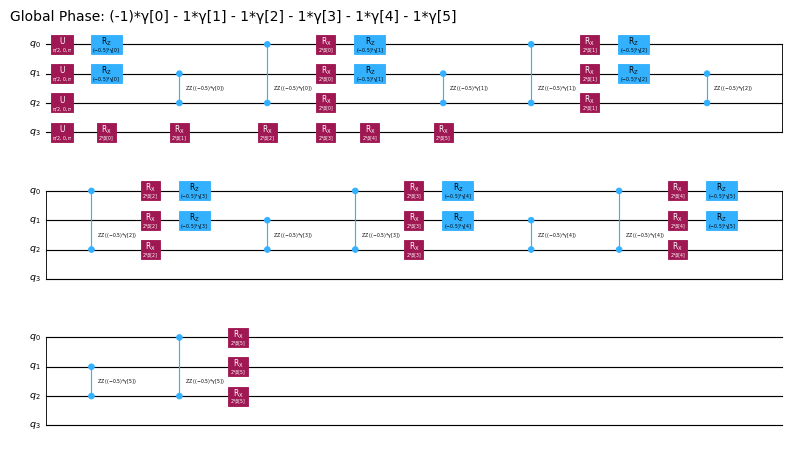

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(β[2]), ParameterVectorElement(β[3]), ParameterVectorElement(β[4]), ParameterVectorElement(β[5]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1]), ParameterVectorElement(γ[2]), ParameterVectorElement(γ[3]), ParameterVectorElement(γ[4]), ParameterVectorElement(γ[5])])


/home/dghezzi/envs/qiskit_env/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/dghezzi/envs/qiskit_env/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/dghezzi/envs/qiskit_env/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 5.187725123922959e-07
           x: [ 1.318e+00  7.110e-01  7.045e-01  1.200e+00 -7.587e-01
                1.457e-01  1.184e-01 -9.988e-01 -1.647e+00 -2.434e+00
                7.519e-01  2.038e+00]
         nit: 32
         jac: [-1.972e-05  2.714e-04  4.738e-04 -1.907e-04 -3.393e-04
               -3.046e-05  3.427e-04  2.081e-04 -2.508e-04  4.052e-04
                1.172e-04 -4.302e-05]
        nfev: 429
        njev: 32
 multipliers: []
State |1000>: 50074 shots. Num violated: 0
State |0000>: 49926 shots. Num violated: 0


In [21]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.visualization import plot_histogram
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from scipy.optimize import minimize
import matplotlib.pyplot as plt


formula = sat2_generator.generate()
print(formula)

sparse_pauli_list = sparse_pauli_list_ksat(formula)
print(sparse_pauli_list)

cost_hamiltonian = SparsePauliOp.from_list(sparse_pauli_list)
print(cost_hamiltonian)

qaoa_reps = 6 # this is p
ansatz = QAOAAnsatz(cost_hamiltonian, reps=qaoa_reps)
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
ansatz.decompose(reps=2).draw("mpl", ax=ax)
plt.show()
print(ansatz.parameters)




estimator = StatevectorEstimator()
initial_params = np.random.uniform(0, 0.1, size=ansatz.num_parameters)

def cost_function(params):
    pub = (ansatz, cost_hamiltonian, params)
    job = estimator.run([pub])
    result = job.result()[0]
    return result.data.evs

opt_result = minimize(cost_function, initial_params, method="SLSQP", options={"maxiter":100})
print(opt_result)

optimal_circuit = ansatz.assign_parameters(opt_result.x)
optimal_circuit.measure_all()

sampler = StatevectorSampler(default_shots=100000)

job = sampler.run([(optimal_circuit,)])
sample_result = job.result()[0]

counts = sample_result.data.meas.get_counts()

sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True))
for bitstring, count in sorted_counts.items():
    print(f"State |{bitstring}>: {count} shots. Num violated: {count_violated_clauses(formula, bitstring)}")

In [19]:
def success_probability(counts, formula):
    total_shots = sum(counts.values())
    success_shots = sum(count for bitstring, count in counts.items() if count_violated_clauses(formula, bitstring) == 0)
    return success_shots / total_shots

[(-1, -4), (-2, 3), (1, -3), (-1, 4)]


/home/dghezzi/envs/qiskit_env/lib/python3.14/site-packages/qiskit/visualization/counts_visualization.py:391: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_ylim, min([1.1 * sum(all_vals), max(1.1 * val for val in all_vals)])])


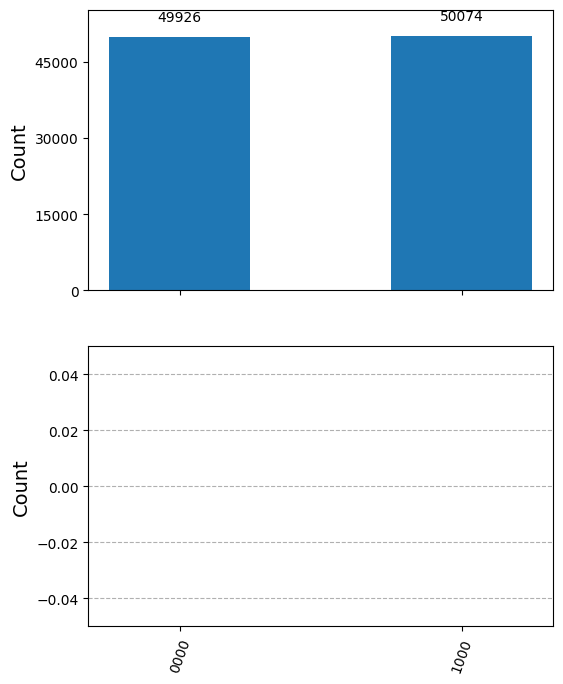

Success probability: 1.0000


In [22]:
print(formula)
fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
plot_histogram(counts, ax=axes[0])

violated = {}
for bitstring, _ in sorted_counts.items():
    violated[bitstring] = count_violated_clauses(formula, bitstring)
plot_histogram(violated, ax=axes[1])
plt.show()

# Success probability
success_prob = success_probability(counts, formula)
print(f"Success probability: {success_prob:.4f}")

## Benchmarking 
We fix n = 4 and we vary p and m

In [27]:
!mkdir -p results_2sat

In [ ]:
import pandas as pd
import time

run_name = "test_run1" # OCCHIO A NON SOVRASCRIVERE
n = 4
N_iterations = 10
N_samples = 10000
verbose = True

optimizer = "Nelder-Mead" # "SLSQP", "COBYLA"
p_list = [1, 2, 4]
m_list = np.arange(1, 9, 1)

results = []

estimator = StatevectorEstimator()
sampler = StatevectorSampler(default_shots=N_samples)

# "grid search" over all combinations of p and m (10 minimizations for each (p,m) combination to get averages)
for p in p_list:
    for m in m_list:
        for trial_idx in range(N_iterations):

            time_start = time.time()

            # Generate the specific problem instance
            sat2_generator = kSATGenerator(num_clauses=m, num_vars=n, k=2, seed=trial_idx)
            formula = sat2_generator.generate()
            
            sparse_pauli_list = sparse_pauli_list_ksat(formula)
            cost_hamiltonian = SparsePauliOp.from_list(sparse_pauli_list)
            
            # Ansatz must be rebuilt each time because the Hamiltonian changes
            ansatz = QAOAAnsatz(cost_hamiltonian, reps=p)

            initial_params = np.random.uniform(0, 0.1, size=ansatz.num_parameters)

            def cost_function(params):
                pub = (ansatz, cost_hamiltonian, params)
                job = estimator.run([pub])
                result = job.result()[0]
                return result.data.evs

            # classical optimization with scipy
            opt_result = minimize(
                cost_function, 
                initial_params, 
                method=optimizer, 
                options={"maxiter":100}, 
            )
            
            # extract optimal parameters and sample from the optimal circuit
            optimal_circuit = ansatz.assign_parameters(opt_result.x)
            optimal_circuit.measure_all()
            job = sampler.run([(optimal_circuit,)])
            sample_result = job.result()[0]
            counts = sample_result.data.meas.get_counts()

            energy_Hc = opt_result.fun
            success_prob = success_probability(counts, formula)

            time_end = time.time()

            if verbose:
                print(f"(p={p}, m={m}, iter {trial_idx}) done: energy_Hc={energy_Hc:.4f}, success_prob={success_prob:.4f}, time_sec={time_end - time_start:.2f}")

            results.append({
                "optimizer": optimizer,
                "p": p,
                "m": m,
                "trial": trial_idx,
                "energy_Hc": energy_Hc,
                "success_prob": success_prob,
                "time_sec": time_end - time_start,
            })

# convert the list of dictionaries into a Pandas DataFrame
df_results = pd.DataFrame(results)
df_results.to_csv(f"results_2sat/{run_name}_qaoa_results.csv", index=False)

# Group by 'p' and 'm', then calculate the mean and std across the 10 trials
summary_df = df_results.groupby(['p', 'm'])[['energy_Hc', 'success_prob', 'time_sec']].agg(['mean', 'std']).reset_index()
summary_df.columns = ['_'.join(col).strip('_') for col in summary_df.columns.values]


print("Execution complete. Head of summary statistics:")
print(summary_df.head())

/home/dghezzi/envs/qiskit_env/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/dghezzi/envs/qiskit_env/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/dghezzi/envs/qiskit_env/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Execution complete. Head of summary statistics:
   p  m     energy_Hc  success_prob
0  1  1  3.793340e-10       1.00000
1  1  2  2.964139e-02       0.97171
2  1  3  1.547871e-01       0.85087
3  1  4  3.305461e-01       0.68554
4  1  5  5.222119e-01       0.51450


In [ ]:
df_results

,optimizer,p,m,trial,energy_Hc,success_prob,time_sec
0,Nelder-Mead,1,1,0,2.984620e-10,1.0000,3.035577
1,Nelder-Mead,1,1,1,3.202646e-10,1.0000,3.186091
2,Nelder-Mead,1,1,2,1.695625e-10,1.0000,2.450523
3,Nelder-Mead,1,1,3,2.448322e-10,1.0000,1.573826
4,Nelder-Mead,1,1,4,1.290157e-09,1.0000,1.955651
...,...,...,...,...,...,...,...
235,Nelder-Mead,4,8,5,9.334414e-01,0.3296,11.015842
236,Nelder-Mead,4,8,6,1.204369e+00,0.3464,12.207783
237,Nelder-Mead,4,8,7,8.576880e-01,0.5359,11.767574
238,Nelder-Mead,4,8,8,1.235916e+00,0.3154,10.834643


In [48]:
summary_df = df_results.groupby(['p', 'm'])[['energy_Hc', 'success_prob', 'time_sec']].agg(['mean', 'std']).reset_index()
summary_df.columns = ['_'.join(col).strip('_') for col in summary_df.columns.values]
std_cols = ['energy_Hc_std', 'success_prob_std', 'time_sec_std']
summary_df[std_cols] = summary_df[std_cols] / np.sqrt(N_iterations) # std mean
summary_df

,p,m,energy_Hc_mean,energy_Hc_std,success_prob_mean,success_prob_std,time_sec_mean,time_sec_std
0,1,1,3.793340e-10,1.030987e-10,1.00000,0.000000,2.180084,0.221866
1,1,2,2.964139e-02,8.940664e-03,0.97171,0.008976,2.195115,0.121962
2,1,3,1.547871e-01,3.700613e-02,0.85087,0.038092,2.250991,0.127917
3,1,4,3.305461e-01,5.503572e-02,0.68554,0.055008,2.212548,0.136331
4,1,5,5.222119e-01,4.893042e-02,0.51450,0.053167,2.414299,0.132518
5,1,6,7.216361e-01,6.171772e-02,0.39256,0.073456,2.240425,0.134993
6,1,7,9.092495e-01,8.440101e-02,0.27775,0.087300,2.436709,0.092903
7,1,8,1.090636e+00,9.535412e-02,0.21992,0.083279,2.274888,0.111012
8,2,1,1.261588e-09,4.969406e-10,1.00000,0.000000,5.849841,0.502410
9,2,2,1.636796e-02,6.171020e-03,0.98563,0.005559,6.819798,0.405124


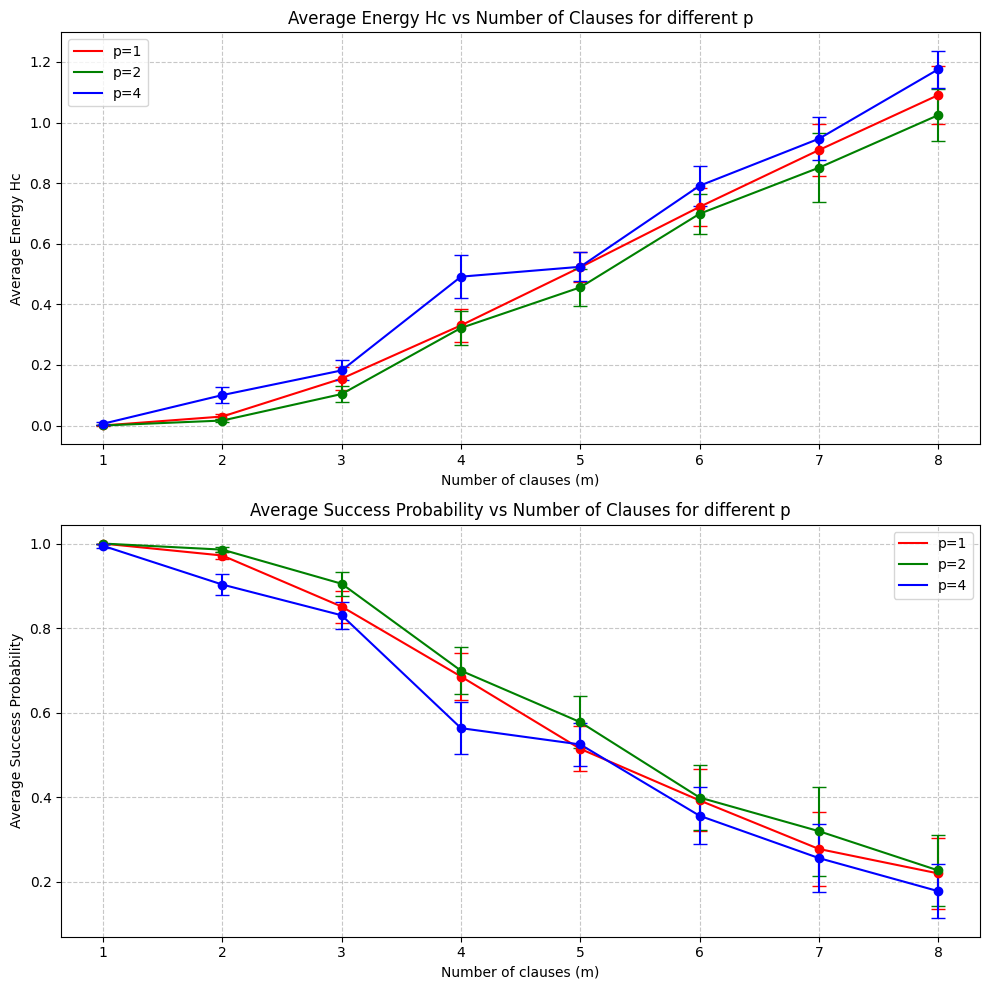

In [49]:
# Plotting the results from summary_df
# Hc energy and success probability vs m for different p values

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
colors = ['red', 'green', 'blue']

for idx, p in enumerate(p_list):
    subset = summary_df[summary_df['p'] == p]
    ax[0].plot(subset['m'], subset['energy_Hc_mean'], marker='', label=f'p={p}', color=colors[idx])
    ax[0].errorbar(subset['m'], subset['energy_Hc_mean'], yerr=subset['energy_Hc_std'], fmt='o', capsize=5, color=colors[idx])
    ax[1].plot(subset['m'], subset['success_prob_mean'], marker='', label=f'p={p}', color=colors[idx])
    ax[1].errorbar(subset['m'], subset['success_prob_mean'], yerr=subset['success_prob_std'], fmt='o', capsize=5, color=colors[idx])

# plot 1 (Energy)
ax[0].set_xlabel('Number of clauses (m)')
ax[0].set_ylabel('Average Energy Hc')
ax[0].set_title('Average Energy Hc vs Number of Clauses for different p')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

# plot 2 (Success Probability)
ax[1].set_xlabel('Number of clauses (m)')
ax[1].set_ylabel('Average Success Probability')
ax[1].set_title('Average Success Probability vs Number of Clauses for different p')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

non ha troppo senso perchè probabilmente stiamo guardando un piccolissimo "spazio delle fasi": queste statistiche non sono affidabili, troppe poche iterazioni